# 04 - Pitch Type Frequency

## MLB Ballpark Effects on Pitch Type Frequency & Contact Quality

This notebook conducts **Layer 1** of a three-layer analytical framework — examining whether certain pitch types are thrown at meaningfully different rates across MLB ballparks.

Pitch type proportions are computed per park and compared against the league-wide baseline established in `02_eda.ipynb` (Fastball 55.85%, Breaking 29.83%, Offspeed 14.32%). Deviations from that baseline are signal of interest here.

No contact quality or swing outcome data is used in this notebook — only pitch type composition. Outcome and quality layers follow in notebooks 5 and 6.

*Sample*: 173,137 swings across 29 parks (2023–2025 pooled)
<br>
*Granularity*: Park-level pitch type proportions (Level 1 classification of FB, BB, Offspead)
<br>
*Baseline*: League-wide pitch type frequencies from EDA

___
## 1) Setup & Data Load

In [2]:
# Setup

import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path

# ── Database connection ──────────────────────────────────────────────────────
DB_PATH = Path(r"C:\Users\Bryce Gelarden\OneDrive - Indiana University\Documents\Github - brycemgelarden\MLB_Ballpark_Factor_Analysis\database\mlb_ballpark_effects.db")

conn = sqlite3.connect(DB_PATH)
df = pd.read_sql_query("SELECT * FROM swings", conn)
conn.close()

# ── Color scheme (project-wide) ──────────────────────────────────────────────
COLORS = {
    "Fastball":  "#1F4E79",
    "Breaking":  "#2E75B6",
    "Offspeed":  "#9DC3E6",
    "reference": "#9DC3E6",
}

In [3]:
# Quick Validation

n_rows  = len(df)
n_parks = df["home_team"].nunique()
parks   = sorted(df["home_team"].unique())

print(f"Rows loaded:  {n_rows:,}")
print(f"Parks loaded: {n_parks}")
print(f"\nParks ({n_parks}):\n{parks}")

# surface any unexpected pitch_category values early
print(f"\nPitch categories present:\n{df['pitch_category'].value_counts()}")

Rows loaded:  173,137
Parks loaded: 29

Parks (29):
['ATL', 'AZ', 'BAL', 'BOS', 'CHC', 'CIN', 'CLE', 'COL', 'CWS', 'DET', 'HOU', 'KC', 'LAA', 'LAD', 'MIA', 'MIL', 'MIN', 'NYM', 'NYY', 'PHI', 'PIT', 'SD', 'SEA', 'SF', 'STL', 'TB', 'TEX', 'TOR', 'WSH']

Pitch categories present:
pitch_category
Fastball    96689
Breaking    51650
Offspeed    24798
Name: count, dtype: int64


___
## 2) League-Wide Baseline (Reference Point)

In [ ]:
# recompute from sample rather than hard-coding

league_counts = df["pitch_category"].value_counts()
league_props  = df["pitch_category"].value_counts(normalize=True)

league_baseline = pd.DataFrame({
    "n":          league_counts,
    "proportion": league_props,
    "pct":        league_props * 100,
}).loc[["Fastball", "Breaking", "Offspeed"]] 

print(f"League-Wide Baseline  (n = {len(df):,})\n")
print(league_baseline.to_string())

League-Wide Baseline  (n = 173,137)

                    n  proportion        pct
pitch_category                              
Fastball        96689    0.558454  55.845371
Breaking        51650    0.298319  29.831867
Offspeed        24798    0.143228  14.322762


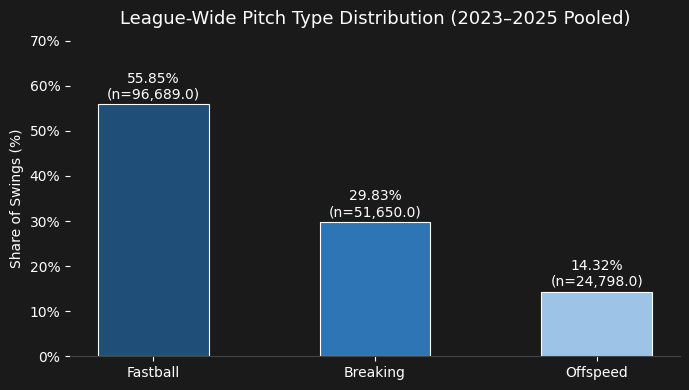

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.bar(
    league_baseline.index,
    league_baseline["pct"],
    color=[COLORS[c] for c in league_baseline.index],
    width=0.5,
    edgecolor="white",
    linewidth=0.8,
)

# label each bar with percentage
for i, (cat, row) in enumerate(league_baseline.iterrows()):
    ax.text(
        i, row["pct"] + 0.5,
        f"{row['pct']:.2f}%\n(n={row['n']:,})",
        ha="center", va="bottom",
        fontsize=10, color="white"
    )

ax.set_title("League-Wide Pitch Type Distribution (2023–2025 Pooled)", 
             fontsize=13, pad=12, color="white")
ax.set_ylabel("Share of Swings (%)", color="white")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylim(0, 70)

ax.set_facecolor("#1a1a1a")
fig.patch.set_facecolor("#1a1a1a")
ax.tick_params(colors="white")
ax.spines[["top", "right", "left"]].set_visible(False)
ax.spines["bottom"].set_color("#444444")

plt.tight_layout()
plt.show()

___
## 3) Park-Level Pitch Type Proportions (Level 1)

___
## 4) Deviation from Baseline

___
## 5) Statistical Significance

Chi-Square GOF test for each park against league distribution

___
## 6) Individual Pitch Code Breakdown (Level 2)

___
## 7) Handedness Cut (Metadata Check)

___
## 8) Observations & Forward Look